In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sp = pd.read_csv('/content/StudentsPerformance.csv')

In [4]:
sp.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [5]:
sp.shape

(1000, 8)

In [6]:
sp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


In [7]:
sp.isnull().sum()

,0
gender,0
race_ethnicity,0
parental_level_of_education,0
lunch,0
test_preparation_course,0
math_score,0
reading_score,0
writing_score,0


In [8]:
sp["average_score"] = (sp["math_score"]+sp['reading_score']+sp["writing_score"])/3

In [9]:
sp['average_score']

,average_score
0,72.666667
1,82.333333
2,92.666667
3,49.333333
4,76.333333
...,...
995,94.000000
996,57.333333
997,65.000000
998,74.333333


In [10]:
sp =sp.drop(['math_score','reading_score','writing_score'], axis =1)

In [11]:
sp

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,average_score
0,female,group B,bachelor's degree,standard,none,72.666667
1,female,group C,some college,standard,completed,82.333333
2,female,group B,master's degree,standard,none,92.666667
3,male,group A,associate's degree,free/reduced,none,49.333333
4,male,group C,some college,standard,none,76.333333
...,...,...,...,...,...,...
995,female,group E,master's degree,standard,completed,94.000000
996,male,group C,high school,free/reduced,none,57.333333
997,female,group C,high school,free/reduced,completed,65.000000
998,female,group D,some college,standard,completed,74.333333


In [12]:
sp['parental_level_of_education'] = sp[
    'parental_level_of_education'
].replace({'some high school': 'high school','some college':'college',"bachelor's degree" :'bachelors',"master's degree":'masters',"associate's degree":'associates_degree'})


In [13]:
sp['parental_level_of_education'].value_counts()

,count
parental_level_of_education,
high school,375
college,226
associates_degree,222
bachelors,118
masters,59


In [14]:
sp['gender'].value_counts()

,count
gender,
female,518
male,482


In [15]:
sp['race_ethnicity'].value_counts()

,count
race_ethnicity,
group C,319
group D,262
group B,190
group E,140
group A,89


In [16]:
sp['lunch'].value_counts()

,count
lunch,
standard,645
free/reduced,355


In [17]:
sp['test_preparation_course'].value_counts()

,count
test_preparation_course,
none,642
completed,358


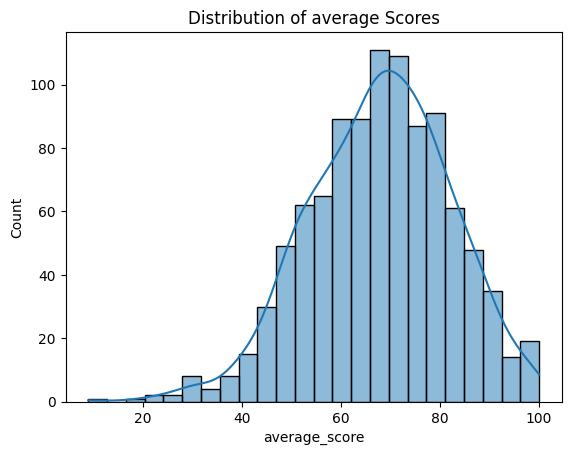

In [18]:
sns.histplot(sp['average_score'], kde=True)
plt.title("Distribution of average Scores")
plt.show()

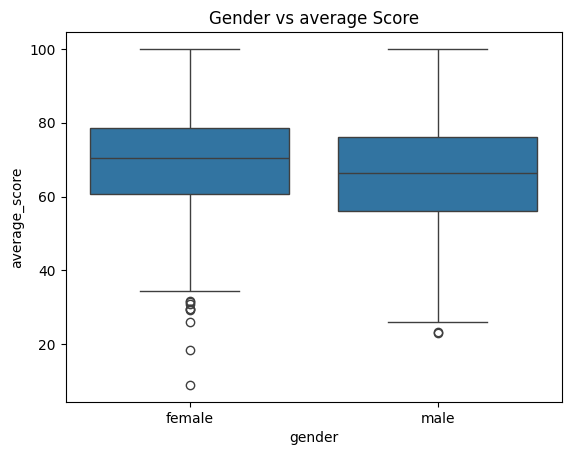

In [19]:
sns.boxplot(x='gender', y='average_score', data=sp)
plt.title("Gender vs average Score")
plt.show()

In [20]:
minimum,Q1,median,Q3,maximum=np.quantile(sp['average_score'],[0,0.25,0.50,0.75,1.0])
minimum,Q1,median,Q3,maximum

(np.float64(9.0),
 np.float64(58.333333333333336),
 np.float64(68.33333333333333),
 np.float64(77.66666666666667),
 np.float64(100.0))

In [21]:
IQR=Q3-Q1
print(IQR)

19.333333333333336


In [22]:
lower_fence=Q1-1.5*(IQR)
higher_fence=Q3+1.5*(IQR)
print(lower_fence)
print(higher_fence)

29.333333333333332
106.66666666666667


<Axes: ylabel='average_score'>

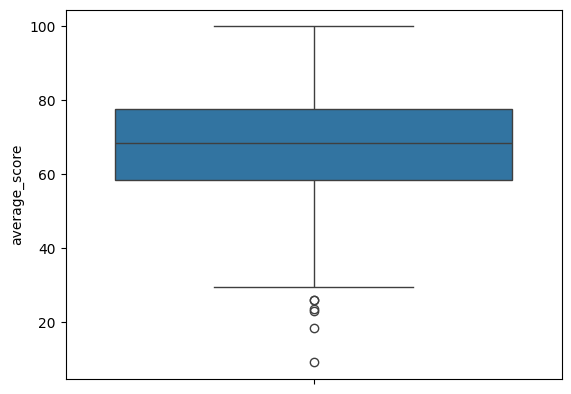

In [23]:
sns.boxplot(sp['average_score'])

In [24]:
sp[sp['average_score']<lower_fence]

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,average_score
17,female,group B,high school,free/reduced,none,26.000000
59,female,group C,high school,free/reduced,none,9.000000
76,male,group E,high school,standard,none,26.000000
327,male,group A,college,free/reduced,none,23.333333
596,male,group B,high school,free/reduced,none,23.000000
980,female,group B,high school,free/reduced,none,18.333333


In [25]:
sp = sp[
    (sp['average_score'] >= lower_fence) &
    (sp['average_score'] <= higher_fence)]

In [26]:
sp['average_score']

,average_score
0,72.666667
1,82.333333
2,92.666667
3,49.333333
4,76.333333
...,...
995,94.000000
996,57.333333
997,65.000000
998,74.333333


In [27]:
sp

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,average_score
0,female,group B,bachelors,standard,none,72.666667
1,female,group C,college,standard,completed,82.333333
2,female,group B,masters,standard,none,92.666667
3,male,group A,associates_degree,free/reduced,none,49.333333
4,male,group C,college,standard,none,76.333333
...,...,...,...,...,...,...
995,female,group E,masters,standard,completed,94.000000
996,male,group C,high school,free/reduced,none,57.333333
997,female,group C,high school,free/reduced,completed,65.000000
998,female,group D,college,standard,completed,74.333333


In [28]:
sp['parental_level_of_education'].value_counts()

,count
parental_level_of_education,
high school,370
college,225
associates_degree,222
bachelors,118
masters,59


In [29]:
print(sp.isnull().sum())

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
average_score                  0
dtype: int64


In [30]:
from sklearn.preprocessing import OrdinalEncoder

In [31]:
encoder=OrdinalEncoder(categories=[["high school","college","associates_degree","bachelors","masters" ]])

In [32]:
encoded =encoder.fit_transform(sp[['parental_level_of_education']])

In [33]:
encoded

array([[3.],
       [1.],
       [4.],
       [2.],
       [1.],
       [2.],
       [1.],
       [1.],
       [0.],
       [0.],
       [2.],
       [2.],
       [0.],
       [1.],
       [4.],
       [0.],
       [0.],
       [4.],
       [2.],
       [0.],
       [1.],
       [1.],
       [0.],
       [3.],
       [4.],
       [1.],
       [3.],
       [0.],
       [4.],
       [1.],
       [1.],
       [4.],
       [1.],
       [1.],
       [2.],
       [2.],
       [0.],
       [2.],
       [2.],
       [2.],
       [2.],
       [2.],
       [1.],
       [2.],
       [2.],
       [2.],
       [0.],
       [2.],
       [0.],
       [1.],
       [2.],
       [1.],
       [0.],
       [0.],
       [0.],
       [2.],
       [2.],
       [1.],
       [3.],
       [0.],
       [2.],
       [2.],
       [0.],
       [0.],
       [0.],
       [1.],
       [2.],
       [2.],
       [1.],
       [1.],
       [2.],
       [0.],
       [0.],
       [2.],
       [3.],
       [0.],
       [4.],

In [34]:
encoder_sp=pd.DataFrame(encoded,columns=encoder.get_feature_names_out())

In [35]:
encoder_sp

,parental_level_of_education
0,3.0
1,1.0
2,4.0
3,2.0
4,1.0
...,...
989,4.0
990,0.0
991,0.0
992,1.0


In [36]:
encoder_sp.columns = ['parent_edu_encoded']

In [37]:
sp = sp.reset_index(drop = True)

In [38]:
encoder_sp = encoder_sp.reset_index(drop=True)

In [39]:
sp = pd.concat([sp,encoder_sp],axis =1)

In [40]:
sp

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,average_score,parent_edu_encoded
0,female,group B,bachelors,standard,none,72.666667,3.0
1,female,group C,college,standard,completed,82.333333,1.0
2,female,group B,masters,standard,none,92.666667,4.0
3,male,group A,associates_degree,free/reduced,none,49.333333,2.0
4,male,group C,college,standard,none,76.333333,1.0
...,...,...,...,...,...,...,...
989,female,group E,masters,standard,completed,94.000000,4.0
990,male,group C,high school,free/reduced,none,57.333333,0.0
991,female,group C,high school,free/reduced,completed,65.000000,0.0
992,female,group D,college,standard,completed,74.333333,1.0


In [41]:
from sklearn.preprocessing import OneHotEncoder

In [42]:
encoder_o=OneHotEncoder()

In [43]:
encoder = pd.DataFrame({
    'gender': ['male', 'female']
})

In [44]:
encoded=encoder_o.fit_transform(sp[['gender']]).toarray()

In [45]:
encoded

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [46]:
encoder_sp=pd.DataFrame(encoded,columns=encoder_o.get_feature_names_out())

In [47]:
encoder_sp

,gender_female,gender_male
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,0.0,1.0
4,0.0,1.0
...,...,...
989,1.0,0.0
990,0.0,1.0
991,1.0,0.0
992,1.0,0.0


In [48]:
sp = sp.drop('parental_level_of_education', axis=1)

In [49]:
sp = pd.concat([sp,encoder_sp],axis=1)

In [50]:
sp

,gender,race_ethnicity,lunch,test_preparation_course,average_score,parent_edu_encoded,gender_female,gender_male
0,female,group B,standard,none,72.666667,3.0,1.0,0.0
1,female,group C,standard,completed,82.333333,1.0,1.0,0.0
2,female,group B,standard,none,92.666667,4.0,1.0,0.0
3,male,group A,free/reduced,none,49.333333,2.0,0.0,1.0
4,male,group C,standard,none,76.333333,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...
989,female,group E,standard,completed,94.000000,4.0,1.0,0.0
990,male,group C,free/reduced,none,57.333333,0.0,0.0,1.0
991,female,group C,free/reduced,completed,65.000000,0.0,1.0,0.0
992,female,group D,standard,completed,74.333333,1.0,1.0,0.0


In [51]:
sp = sp.drop('gender', axis=1)

In [52]:
sp

,race_ethnicity,lunch,test_preparation_course,average_score,parent_edu_encoded,gender_female,gender_male
0,group B,standard,none,72.666667,3.0,1.0,0.0
1,group C,standard,completed,82.333333,1.0,1.0,0.0
2,group B,standard,none,92.666667,4.0,1.0,0.0
3,group A,free/reduced,none,49.333333,2.0,0.0,1.0
4,group C,standard,none,76.333333,1.0,0.0,1.0
...,...,...,...,...,...,...,...
989,group E,standard,completed,94.000000,4.0,1.0,0.0
990,group C,free/reduced,none,57.333333,0.0,0.0,1.0
991,group C,free/reduced,completed,65.000000,0.0,1.0,0.0
992,group D,standard,completed,74.333333,1.0,1.0,0.0


In [53]:
from sklearn.preprocessing import OneHotEncoder

In [54]:
encoder_race=OneHotEncoder()

In [55]:
encoded= encoder_race.fit_transform(sp[['race_ethnicity']]).toarray()

In [56]:
encoded_race = pd.DataFrame(
    encoded,
    columns=encoder_race.get_feature_names_out()
)

In [57]:
encoded_race

,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E
0,0.0,1.0,0.0,0.0,0.0
1,0.0,0.0,1.0,0.0,0.0
2,0.0,1.0,0.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0
4,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...
989,0.0,0.0,0.0,0.0,1.0
990,0.0,0.0,1.0,0.0,0.0
991,0.0,0.0,1.0,0.0,0.0
992,0.0,0.0,0.0,1.0,0.0


In [58]:
sp = sp.drop('race_ethnicity', axis=1)

In [59]:
sp = pd.concat([sp,encoded_race],axis=1)

In [60]:
sp

,lunch,test_preparation_course,average_score,parent_edu_encoded,gender_female,gender_male,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E
0,standard,none,72.666667,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
1,standard,completed,82.333333,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
2,standard,none,92.666667,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,free/reduced,none,49.333333,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
4,standard,none,76.333333,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
989,standard,completed,94.000000,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
990,free/reduced,none,57.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
991,free/reduced,completed,65.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
992,standard,completed,74.333333,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0


In [61]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()

In [62]:
encoded_lunch = lbl_encoder.fit_transform(sp[['lunch']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [63]:
encoded_lunch_df = pd.DataFrame(encoded_lunch,
    columns=['lunch_encoded'])

In [64]:
lbl_encoder.transform([['standard']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([1])

In [65]:
lbl_encoder.fit_transform([['free/reduced']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([0])

In [66]:
sp = pd.concat([sp, encoded_lunch_df], axis=1)

In [67]:
sp

,lunch,test_preparation_course,average_score,parent_edu_encoded,gender_female,gender_male,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,lunch_encoded
0,standard,none,72.666667,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1,standard,completed,82.333333,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
2,standard,none,92.666667,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,free/reduced,none,49.333333,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0
4,standard,none,76.333333,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
989,standard,completed,94.000000,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
990,free/reduced,none,57.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
991,free/reduced,completed,65.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
992,standard,completed,74.333333,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [68]:
sp = sp.drop(['lunch'],axis = 1)

In [69]:
sp

,test_preparation_course,average_score,parent_edu_encoded,gender_female,gender_male,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,lunch_encoded
0,none,72.666667,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
1,completed,82.333333,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1
2,none,92.666667,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1
3,none,49.333333,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0
4,none,76.333333,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...
989,completed,94.000000,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1
990,none,57.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0
991,completed,65.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0
992,completed,74.333333,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1


In [70]:
from sklearn.preprocessing import LabelEncoder
lbl_encoder=LabelEncoder()

In [71]:
encoded_test = lbl_encoder.fit_transform(sp[['test_preparation_course']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [72]:
encoded_test_df = pd.DataFrame(encoded_test,
    columns=['test_encoded'])

In [73]:
lbl_encoder.transform([['completed']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([0])

In [74]:
lbl_encoder.transform([['none']])

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


array([1])

In [75]:
sp = pd.concat([sp, encoded_test_df], axis=1)

In [76]:
sp = sp.drop(['test_preparation_course'],axis = 1)

In [77]:
sp

,average_score,parent_edu_encoded,gender_female,gender_male,race_ethnicity_group A,race_ethnicity_group B,race_ethnicity_group C,race_ethnicity_group D,race_ethnicity_group E,lunch_encoded,test_encoded
0,72.666667,3.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1
1,82.333333,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1,0
2,92.666667,4.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1,1
3,49.333333,2.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0,1
4,76.333333,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1,1
...,...,...,...,...,...,...,...,...,...,...,...
989,94.000000,4.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1,0
990,57.333333,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0,1
991,65.000000,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0,0
992,74.333333,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1,0


In [78]:
X = sp[['parent_edu_encoded','gender_female', 'gender_male',
       'race_ethnicity_group A', 'race_ethnicity_group B',
       'race_ethnicity_group C', 'race_ethnicity_group D',
       'race_ethnicity_group E', 'lunch_encoded', 'test_encoded']]
y = sp['average_score']

In [79]:
X.shape

(994, 10)

In [80]:
y.shape

(994,)

In [81]:
from sklearn.model_selection import train_test_split

In [82]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [83]:
from sklearn.preprocessing import StandardScaler

In [84]:
scaler = StandardScaler()
X_train=scaler.fit_transform(X_train)

In [85]:
X_train

array([[ 0.58119324,  0.97481372, -0.97481372, ..., -0.40279832,
         0.71495188,  0.7671285 ],
       [-1.00775709,  0.97481372, -0.97481372, ..., -0.40279832,
        -1.39869554,  0.7671285 ],
       [-1.00775709, -1.02583702,  1.02583702, ..., -0.40279832,
         0.71495188, -1.30356257],
       ...,
       [-0.21328192, -1.02583702,  1.02583702, ..., -0.40279832,
         0.71495188, -1.30356257],
       [-1.00775709, -1.02583702,  1.02583702, ..., -0.40279832,
         0.71495188, -1.30356257],
       [-0.21328192,  0.97481372, -0.97481372, ..., -0.40279832,
         0.71495188,  0.7671285 ]])

In [86]:
X_test=scaler.transform(X_test)

In [87]:
X_test

array([[-1.00775709, -1.02583702,  1.02583702, ..., -0.40279832,
        -1.39869554,  0.7671285 ],
       [ 0.58119324,  0.97481372, -0.97481372, ..., -0.40279832,
         0.71495188,  0.7671285 ],
       [ 1.37566841, -1.02583702,  1.02583702, ..., -0.40279832,
         0.71495188,  0.7671285 ],
       ...,
       [ 0.58119324, -1.02583702,  1.02583702, ..., -0.40279832,
         0.71495188, -1.30356257],
       [-0.21328192, -1.02583702,  1.02583702, ..., -0.40279832,
        -1.39869554,  0.7671285 ],
       [-1.00775709, -1.02583702,  1.02583702, ..., -0.40279832,
         0.71495188,  0.7671285 ]])

In [88]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [89]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [90]:
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [91]:
y_pred = rf_model.predict(X_test)

In [92]:
print(y_pred[:10])

[55.38600066 71.49233186 64.75470106 64.63791102 59.20281481 53.2888955
 67.1490873  69.17188889 79.04990594 67.31588899]


In [93]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

In [94]:
print("MAE :", mae)

print("MSE :", mse)

print("RMSE :", rmse)

print("R2 Score :", r2)

MAE : 10.398944425251136
MSE : 172.23759311178964
RMSE : 13.123932075098136
R2 Score : 0.09706314049652076


In [95]:
all_predictions = rf_model.predict(X)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


In [104]:
sp['predicted_average_score'] = all_predictions

In [97]:
print(len(sp))
print(len(all_predictions))

994
994


In [98]:
print(sp[['average_score', 'predicted_average_score']].head(10))


   average_score  predicted_average_score
0      72.666667                80.916894
1      82.333333                79.886766
2      92.666667                80.916894
3      49.333333                77.963108
4      76.333333                76.131063
5      77.333333                80.916894
6      91.666667                78.863799
7      40.666667                72.297474
8      65.000000                70.505855
9      49.333333                67.351048


In [99]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

print(importance)

                  Feature  Importance
0      parent_edu_encoded    0.289485
8           lunch_encoded    0.147530
9            test_encoded    0.136606
1           gender_female    0.071372
4  race_ethnicity_group B    0.066821
7  race_ethnicity_group E    0.063584
3  race_ethnicity_group A    0.063572
2             gender_male    0.059255
6  race_ethnicity_group D    0.051839
5  race_ethnicity_group C    0.049936


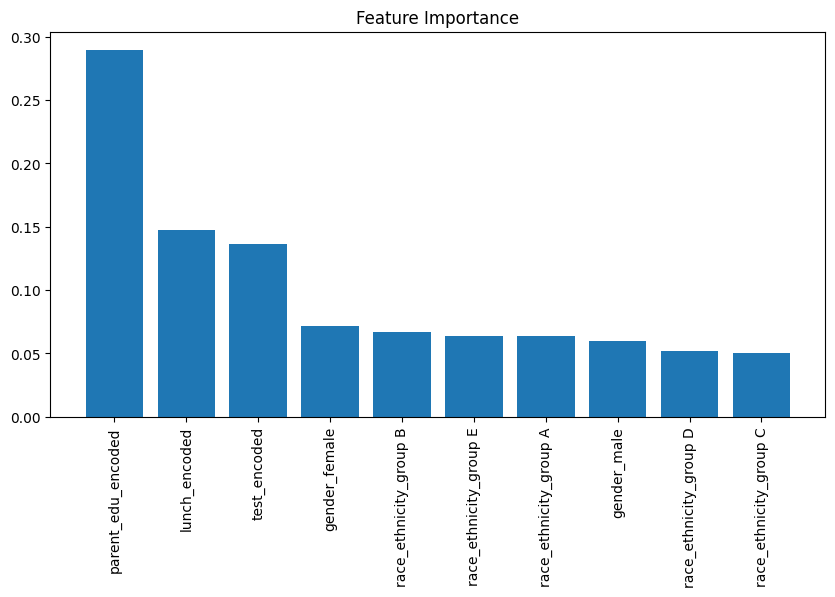

In [100]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(
    importance['Feature'],
    importance['Importance']
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.show()

In [105]:
import pandas as pd

# Example new student data
new_student = pd.DataFrame({
    'parent_edu_encoded': [3],   # use the encoded value from your label encoder
    'gender_female': [1],
    'gender_male': [0],
    'race_ethnicity_group A': [0],
    'race_ethnicity_group B': [0],
    'race_ethnicity_group C': [1],
    'race_ethnicity_group D': [0],
    'race_ethnicity_group E': [0],
    'lunch_encoded': [1],        # encoded value
    'test_encoded': [1]          # encoded value
})

# Scale the data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = rf_model.predict(new_student_scaled)

print("Predicted Average Score:", prediction[0])

Predicted Average Score: 79.88676606753813


In [106]:
import pandas as pd

# Example new student data
new_student = pd.DataFrame({
    'parent_edu_encoded': [2],   # use the encoded value from your label encoder
    'gender_female': [1],
    'gender_male': [0],
    'race_ethnicity_group A': [0],
    'race_ethnicity_group B': [1],
    'race_ethnicity_group C': [0],
    'race_ethnicity_group D': [0],
    'race_ethnicity_group E': [0],
    'lunch_encoded': [1],        # encoded value
    'test_encoded': [1]          # encoded value
})

# Scale the data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = rf_model.predict(new_student_scaled)

print("Predicted Average Score:", prediction[0])

Predicted Average Score: 67.31588899063898


In [108]:
import pandas as pd

# Example new student data
new_student = pd.DataFrame({
    'parent_edu_encoded': [1],   # use the encoded value from your label encoder
    'gender_female': [0],
    'gender_male': [1],
    'race_ethnicity_group A': [0],
    'race_ethnicity_group B': [0],
    'race_ethnicity_group C': [0],
    'race_ethnicity_group D': [0],
    'race_ethnicity_group E': [1],
    'lunch_encoded': [0],        # encoded value
    'test_encoded': [0]          # encoded value
})

# Scale the data
new_student_scaled = scaler.transform(new_student)

# Predict
prediction = rf_model.predict(new_student_scaled)

print("Predicted Average Score:", prediction[0])

Predicted Average Score: 73.4673373015873
